## Import all the necessary config files

In [1]:
from config import *
from utils import *

import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np
import random

np.random.seed(42)
random.seed(42)
#if you get an error here you propoably didnt close the parameters excel sheet

In [2]:
# model name to be included in file names later with the output_title function, creating an iteration subscript, e.g. Run_001
title = 'Run'

## Run the coral model

In [3]:
print(growth_rate_df)

   CoralType  GrowthRate_cm_per_year
0  Branching                     2.5
1    Foliose                     3.0
2      Other                     1.0


In [4]:
# This runs the model once for the number of years selected in the user input files
run_coral_model(PSD_T0, MaxYear) # no PDS_df because it’s a placeholder. It basically asks a user to link SOME data frame to it. Same as run_model_n_times(n_iterations) simply tells a user that there should be some number in those brackets that will become the number of iterations. 

,Year,Branching_Area (%),Foliose_Area (%),Other_Area (%),total_coral_cover (%)
0,0,1.000000,3.000000,4.000000,8.000000
1,1,1.262803,3.555586,4.560680,9.379069
2,2,1.798285,4.858131,5.829449,12.485864
3,3,2.665122,7.050826,7.343465,17.059412
4,4,3.924454,10.186888,9.851316,23.962659
5,5,5.434801,13.626893,12.044515,31.106209
6,6,6.927133,16.826830,14.040539,37.794502
7,7,8.168272,19.788870,16.070755,44.027896
8,8,8.982739,21.744749,17.513898,48.241386
9,9,9.563071,23.005162,18.521750,51.089984


## Plot the change in total coral cover over the years

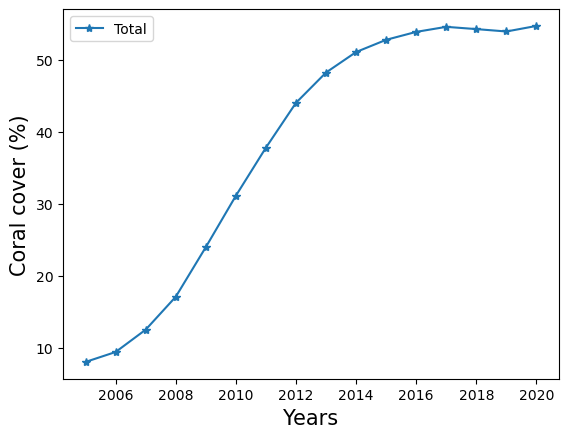

In [5]:
# Build actual years based on row count
n = len(opts.yearly_total_coral_cover_df)
actual_years = range(year_start, year_start + n)

# Plot with actual years as x-values
plt.plot(actual_years,
         opts.yearly_total_coral_cover_df['total_coral_cover (%)'],
         '-*',
         label='Total')

plt.xlabel('Years', fontsize=15)
plt.ylabel('Coral cover (%)', fontsize=15)
plt.legend()

# Make x-axis labels integers only
plt.gca().xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))

plt.show()

## The benthic cover over the years in percentage

In [6]:
opts.yearly_benthic_cover_df

,Year,total_benthic_cover (%),available_substrate (%),hard_substrate (%),dead_coral (%),CCA (%),turfing_algae (%),macro_algae (%),rubble (%),sediment (%),total_cc,unavailable_sub,tot
0,0,89.100000,43.300000,2.400000,4.000000,0.800000,36.100000,36.800000,4.000000,5.000000,8.000000,45.800000,97.100000
1,1,90.620931,42.476487,2.401934,4.577872,0.827496,36.129084,38.064800,3.447899,5.171848,9.379069,45.133333,96.988889
2,2,87.514136,41.308464,2.231272,4.732005,0.828402,33.562043,38.106503,2.876397,5.177514,12.485864,46.109896,99.904225
3,3,82.940588,37.179673,1.981367,4.601900,0.829201,29.803057,38.143248,2.399309,5.182507,17.059412,45.681015,99.920100
4,4,76.037341,30.645515,1.606868,4.065624,0.829928,24.169979,38.176711,2.001178,5.187053,23.962659,45.325179,99.933353
5,5,68.893791,23.806791,1.223211,3.373077,0.830599,18.399129,38.207539,1.668995,5.191242,31.106209,45.031412,99.944412
6,6,62.205498,17.369527,0.868083,2.625768,0.831218,13.057413,38.236036,1.391866,5.195114,37.794502,44.789610,99.953639
7,7,55.972104,11.342403,0.541527,1.831454,0.831793,8.145469,38.262466,1.160690,5.198705,44.027896,44.591038,99.961337
8,8,51.758614,7.297961,0.324804,1.259800,0.832311,4.885594,38.286315,0.967845,5.201945,48.241386,44.428412,99.967759
9,9,48.910016,4.588334,0.181904,0.840040,0.832769,2.736145,38.307372,0.806981,5.204806,51.089984,44.294797,99.973115


## Plot the benthic cover over the years for turfing algae, dead coral, rubble, macro algae and total coral cover in percentage

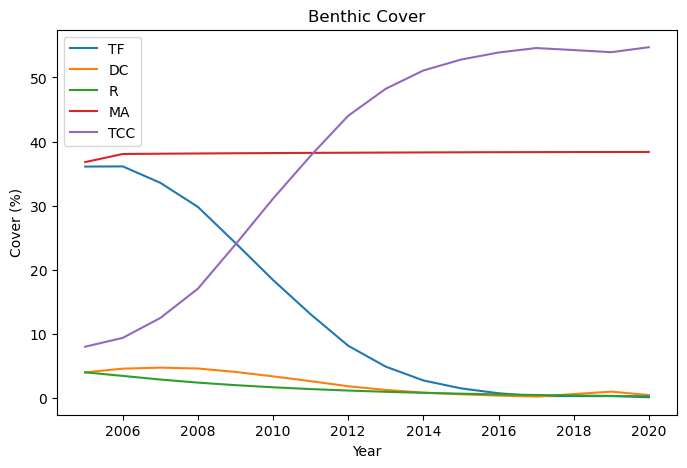

In [7]:
# Make a clean working copy and normalise column names
df = opts.yearly_benthic_cover_df.copy()
df.columns = df.columns.str.strip()

# Replace index with actual years
n = len(df)
actual_years = range(year_start, year_start + n)  # real years
df.index = pd.Index(actual_years, name="Year")

# Create a single plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(df['turfing_algae (%)'], label='TF')
ax.plot(df['dead_coral (%)'], label='DC')
ax.plot(df['rubble (%)'], label='R')
ax.plot(df['macro_algae (%)'], label='MA')
ax.plot(df['total_cc'], label='TCC')

ax.set_xlabel('Year')
ax.set_ylabel('Cover (%)')
ax.set_title('Benthic Cover')
ax.legend()

# Force integer year labels
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))

plt.show()

## Export the data frames to excel

In [8]:
# This function exports data frames to Excel 

export_to_excel(opts.yearly_population_df_list,'yearly_population')
export_to_excel(opts.yearly_surface_area_df_list,'yearly_surface_area')
export_to_excel(opts.yearly_total_coral_cover_df,'yearly_total_coral_cover')
export_to_excel(opts.yearly_benthic_cover_df,'yearly_benthic_cover')

## Plots - please enter the years (within model range) for each plot

In [9]:
#Coral Cover Population

#Years you want to be plotted:
Years = 2011, 2015, 2018, 2022

# Check if any requested years are before the start year
if min(Years) < year_start:
    print(f"Error: Requested year {min(Years)} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif max(Years) > year_end:
    print(f"Error: Requested year {max(Years)} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    # Convert them to model years (indices) for the model
    model_years = tuple(year - year_start for year in Years)
    print(model_years)
    # Plot coral population change by type
    plot_coral_type_population_change('Foliose', False, *model_years)

Error: Requested year 2022 is after the end year 2020. Please use years up to 2020.


In [10]:
# This plots the Area of the coral type chosen for different input years
# Other

#Years you want to be plotted:
Years = 2011, 2015, 2018, 2022

# Check if any requested years are before the start year
if min(Years) < year_start:
    print(f"Error: Requested year {min(Years)} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif max(Years) > year_end:
    print(f"Error: Requested year {max(Years)} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    #Convert them to model years (indices) for the model)
    model_years = tuple(year - year_start for year in Years)

    print(model_years)

    #Plot coral area change by type
    plot_coral_type_areal_change('Other', False, *model_years)

Error: Requested year 2022 is after the end year 2020. Please use years up to 2020.


In [11]:
# This plots the Area of the coral type chosen for different input years
# Branching

#Years you want to be plotted:
#Years you want to be plotted:
Years = 2011, 2015, 2018, 2022

# Check if any requested years are before the start year
if min(Years) < year_start:
    print(f"Error: Requested year {min(Years)} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif max(Years) > year_end:
    print(f"Error: Requested year {max(Years)} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    #Convert them to model years (indices) for the model)
    model_years = tuple(year - year_start for year in Years)

    plot_coral_type_areal_change('Branching', False, *model_years)

Error: Requested year 2022 is after the end year 2020. Please use years up to 2020.


In [12]:
# This plots the Area of the coral type chosen for different input years
# Foliose

#Years you want to be plotted:
#Years you want to be plotted:
Years = 2011, 2015, 2018, 2022

# Check if any requested years are before the start year
if min(Years) < year_start:
    print(f"Error: Requested year {min(Years)} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif max(Years) > year_end:
    print(f"Error: Requested year {max(Years)} is after the end year {year_end}. Please use years up to {year_end}.")
else:

    #Convert them to model years (indices) for the model)
    model_years = tuple(year - year_start for year in Years)

    plot_coral_type_areal_change('Foliose',False, *model_years)

Error: Requested year 2022 is after the end year 2020. Please use years up to 2020.


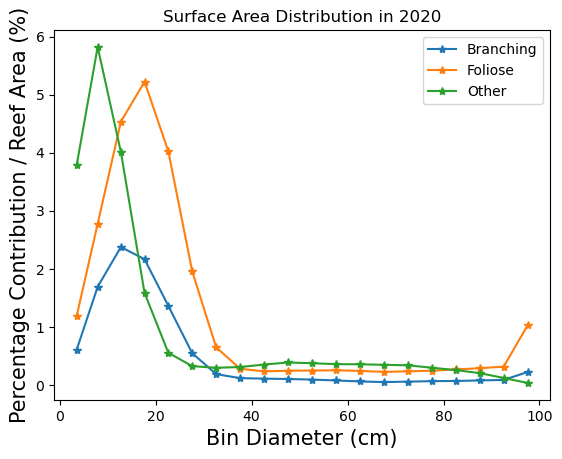

In [13]:
# Plot surface area distribution of different coral types in a given year.

Year = 2020

# Check if the year is within the valid range
if Year < year_start:
    print(f"Error: Requested year {Year} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif Year > year_end:
    print(f"Error: Requested year {Year} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    
    #Convert them to model years (indices) for the model)
    model_year = Year - year_start

    plot_surface_area_distribution(model_year)

In [14]:
# This function plots the percentage population distribution of the bins in a given year. 
# plot_population_distribution_in_percentage(year)
# For example: 100*branching_population_bin_2/total_branching_population 

Year = 2022
# Check if the year is within the valid range
if Year < year_start:
    print(f"Error: Requested year {Year} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif Year > year_end:
    print(f"Error: Requested year {Year} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    
    #Convert them to model years (indices) for the model)
    model_year = Year - year_start

    plot_population_distribution_in_percentage(model_year)

Error: Requested year 2022 is after the end year 2020. Please use years up to 2020.


## Rugosity

In [15]:
# This function calculates the Rugosity and returns them in a list

rugosity_list = get_rugosity_list()
export_to_excel(rugosity_list,'Rugosity')

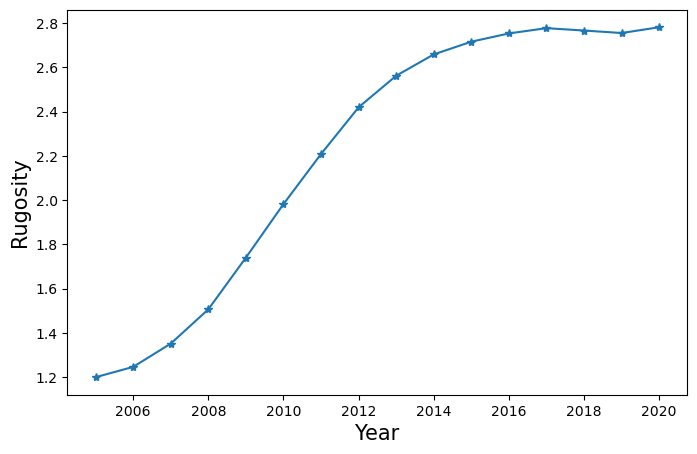

In [16]:
# This function plots the rugosity values over the years

plot_rugosity_year()

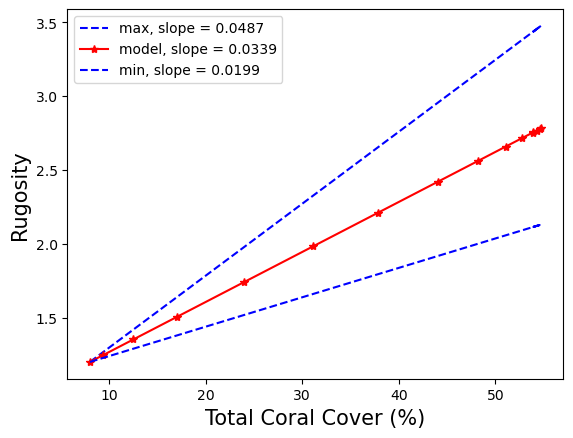

In [17]:
plot_rugosity_total_coral_cover()

## Run simulation for n number of times and plot the total coral cover

In [ ]:
# run the model for n number of iterations (entered in the user inputs)
iteration_df, _ = run_multiple_model_iterations_total_cover(number_of_iterations)

plot_growth_rate_iterations(iteration_df)

In [ ]:
iteration_df

In [ ]:
# Real data input should be saved in the coral_data_and_custom_parameters.xlsx file
# Load the Excel file into a DataFrame

# Load Excel
real_df_raw = pd.read_excel("coral_data_and_custom_parameters.xlsx", sheet_name="Real_Cover")

# Fill + mask (returns a tuple)
real_df, created = fill_nans_columnwise(
    real_df_raw,
    year_col='Year',
    make_full_years=False,
    fallback='mean',
    return_mask=True
)

# Make Year integer-like for display
real_df['Year'] = pd.to_numeric(real_df['Year'], errors='coerce').round().astype('Int64')

value_cols = [c for c in real_df.columns if c != 'Year']

# Build red-highlight styles
styles = created.reindex_like(real_df).replace({True: 'color: red', False: ''})

# Display with exactly 2 decimals (and integer Year)
styler = (
    real_df.style
           .format({c: '{:.2f}' for c in value_cols})
           .format({'Year': '{:.0f}'})
           .apply(lambda _: styles, axis=None)
)
display(styler)


## Run the model through a number iterations for all parameters and export results

In [ ]:
#setting seed to ensure repeatability of runs 

np.random.seed(42)
random.seed(42)

final_df, population_results, percentage_population_results, area_results = run_model_iterations_all_parameters(100)

# Create dataframes
bin_diameters = [i * binSize for i in range(MaxBinId)]
columns = ['MG', 'Year'] + [f'Bin Diameter {d} (cm)' for d in bin_diameters]
population_size_df = pd.DataFrame(population_results, columns=columns)
percentage_population_size_df = pd.DataFrame(percentage_population_results, columns=columns)
area_df = pd.DataFrame(area_results, columns=columns)
area_df.iloc[:, 2:] = (area_df.iloc[:, 2:] * 100).clip(upper=100)

# Print the dataframes - hash these out if you don't want to see them
print("Final DataFrame")
print(final_df)

print("\nPopulation Size DataFrame")
print(population_size_df)

print("\nPercentage Population Size DataFrame")
print(percentage_population_size_df)

print("\nArea DataFrame")
print(area_df)

#Export tables to Excel
run_id = "Run_" + make_run_id(output_folder)               # e.g. '20250808_01'
fname  = f"{run_id}_all_results.xlsx" 

# Define the graph directory path
graph_dir_t = r'output/tables'# '20250808_01_all_results.xlsx'

# fname = '20250808_01_all_results.xlsx'  # if you need this
path = os.path.join(graph_dir_t, fname)

# FIX: Create the directory if it doesn't exist
os.makedirs(graph_dir_t, exist_ok=True)

path   = os.path.join(graph_dir_t, fname)

final_df.to_excel(os.path.join(graph_dir_t, f"{run_id}_final.xlsx"), index=False)
population_size_df.to_excel(os.path.join(graph_dir_t, f"{run_id}_population.xlsx"), index=False)
percentage_population_size_df.to_excel(os.path.join(graph_dir_t, f"{run_id}_population_percentage.xlsx"), index=False)
area_df.to_excel(os.path.join(graph_dir_t, f"{run_id}_area.xlsx"), index=False)

## Create plots for coral cover, benthic cover and rugosity based on the multiple iteration runs

In [ ]:
# Calculate the total coral cover for modelled data
final_df['Total_Coral_Cover (%)'] = final_df['Branching_Area (%)'] + final_df['Foliose_Area (%)'] + final_df['Other_Area (%)']

# Calculate the total coral cover for real data
real_df['Total_Coral_Cover (%)'] = real_df['RealBranching_Area (%)'] + real_df['RealFoliose_Area (%)'] + real_df['RealOther_Area (%)']

# Calculate the average and standard deviation for each morphology
average_branching = final_df.groupby('Year')['Branching_Area (%)'].mean()
std_dev_branching = final_df.groupby('Year')['Branching_Area (%)'].std()

average_foliose = final_df.groupby('Year')['Foliose_Area (%)'].mean()
std_dev_foliose = final_df.groupby('Year')['Foliose_Area (%)'].std()

average_other = final_df.groupby('Year')['Other_Area (%)'].mean()
std_dev_other = final_df.groupby('Year')['Other_Area (%)'].std()

average_total = final_df.groupby('Year')['Total_Coral_Cover (%)'].mean()
std_dev_total = final_df.groupby('Year')['Total_Coral_Cover (%)'].std()

# Calculate the margins for real data (5% absolute above and below)
absolute_margin = 5

real_branching_margin = absolute_margin
real_foliose_margin = absolute_margin
real_other_margin = absolute_margin
real_total_margin = absolute_margin

# Create a figure with 2x2 subplots
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

years = average_branching.index

#Convert model years to actual years for plotting:
actual_years = [year + year_start for year in years]

# Plot Total Coral Cover
axs[0, 0].plot(actual_years, average_total.astype(float), label='Modeled Total Coral Cover', color='blue')
axs[0, 0].fill_between(actual_years, (average_total - std_dev_total).astype(float), (average_total + std_dev_total).astype(float), color='blue', alpha=0.2)
axs[0, 0].plot(real_df['Year'].astype(float), real_df['Total_Coral_Cover (%)'].astype(float), label='Real Total Coral Cover', color='darkblue', linestyle='--')
axs[0, 0].fill_between(real_df['Year'].astype(float), (real_df['Total_Coral_Cover (%)'].astype(float) - real_total_margin), (real_df['Total_Coral_Cover (%)'].astype(float) + real_total_margin), color='darkblue', alpha=0.2)
axs[0, 0].set_title('Total Coral Cover')
axs[0, 0].set_xlabel('Year')
axs[0, 0].set_ylabel('Coral Cover (%)')
axs[0, 0].legend()
axs[0, 0].set_ylim(0, 100)
axs[0, 0].set_xticks(actual_years)
axs[0, 0].set_xticklabels([f'{int(year)}' for year in actual_years])

# Plot Branching, Foliose, and Other Coral Cover
axs[0, 1].plot(actual_years, average_branching.astype(float), label='Modeled Branching', color='blue')
axs[0, 1].fill_between(actual_years, (average_branching - std_dev_branching).astype(float), (average_branching + std_dev_branching).astype(float), color='blue', alpha=0.2)
axs[0, 1].plot(actual_years, average_foliose.astype(float), label='Modeled Foliose', color='fuchsia')
axs[0, 1].fill_between(actual_years, (average_foliose - std_dev_foliose).astype(float), (average_foliose + std_dev_foliose).astype(float), color='fuchsia', alpha=0.2)
axs[0, 1].plot(actual_years, average_other.astype(float), label='Modeled Other', color='orange')
axs[0, 1].fill_between(actual_years, (average_other - std_dev_other).astype(float), (average_other + std_dev_other).astype(float), color='orange', alpha=0.2)
axs[0, 1].plot(real_df['Year'].astype(float), real_df['RealBranching_Area (%)'].astype(float), label='Real Branching', color='darkblue', linestyle='--')
axs[0, 1].fill_between(real_df['Year'].astype(float), (real_df['RealBranching_Area (%)'].astype(float) - real_branching_margin), (real_df['RealBranching_Area (%)'].astype(float) + real_branching_margin), color='darkblue', alpha=0.2)
axs[0, 1].plot(real_df['Year'].astype(float), real_df['RealFoliose_Area (%)'].astype(float), label='Real Foliose', color='darkmagenta', linestyle='--')
axs[0, 1].fill_between(real_df['Year'].astype(float), (real_df['RealFoliose_Area (%)'].astype(float) - real_foliose_margin), (real_df['RealFoliose_Area (%)'].astype(float) + real_foliose_margin), color='darkmagenta', alpha=0.2)
axs[0, 1].plot(real_df['Year'].astype(float), real_df['RealOther_Area (%)'].astype(float), label='Real Other', color='darkorange', linestyle='--')
axs[0, 1].fill_between(real_df['Year'].astype(float), (real_df['RealOther_Area (%)'].astype(float) - real_other_margin), (real_df['RealOther_Area (%)'].astype(float) + real_other_margin), color='darkorange', alpha=0.2)
axs[0, 1].set_title('Branching/Foliose/Other Coral Cover')
axs[0, 1].set_xlabel('Year')
axs[0, 1].set_ylabel('Coral Cover (%)')
axs[0, 1].legend()
axs[0, 1].set_ylim(0, 100)
axs[0, 1].set_xticks(actual_years)
axs[0, 1].set_xticklabels([f'{int(year)}' for year in actual_years])

# Plot Benthic Cover
average_rubble = final_df.groupby('Year')['rubble (%)'].mean()
std_dev_rubble = final_df.groupby('Year')['rubble (%)'].std()
average_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].mean()
std_dev_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].std()
average_as = final_df.groupby('Year')['available_substrate (%)'].mean()
std_dev_as = final_df.groupby('Year')['available_substrate (%)'].std()
average_ma = final_df.groupby('Year')['macro_algae (%)'].mean()
std_dev_ma = final_df.groupby('Year')['macro_algae (%)'].std()
average_sediment = final_df.groupby('Year')['sediment (%)'].mean()
std_dev_sediment = final_df.groupby('Year')['sediment (%)'].std()
axs[1, 0].set_xticks(actual_years)
axs[1, 0].set_xticklabels([f'{int(year)}' for year in actual_years])

#years_benthic = average_rubble.index
#actual_years_benthic = [year + year_start for year in years]

axs[1, 0].plot(actual_years, average_rubble, label='Rubble', color='grey')
axs[1, 0].fill_between(actual_years, average_rubble - std_dev_rubble, average_rubble + std_dev_rubble, color='grey', alpha=0.2)
axs[1, 0].plot(actual_years, average_coral_cover, label='Coral Cover', color='purple')
axs[1, 0].fill_between(actual_years, average_coral_cover - std_dev_coral_cover, average_coral_cover + std_dev_coral_cover, color='purple', alpha=0.2)
axs[1, 0].plot(actual_years, average_as, label='Available Substrate', color='yellow')
axs[1, 0].fill_between(actual_years, average_as - std_dev_as, average_as + std_dev_as, color='yellow', alpha=0.2)
axs[1, 0].plot(actual_years, average_ma, label='Macro Algae', color='darkgreen')
axs[1, 0].fill_between(actual_years, average_ma - std_dev_ma, average_ma + std_dev_ma, color='darkgreen', alpha=0.2)
axs[1, 0].plot(actual_years, average_sediment, label='Sediment', color='brown')
axs[1, 0].fill_between(actual_years, average_sediment - std_dev_sediment, average_sediment + std_dev_sediment, color='brown', alpha=0.2)
axs[1, 0].set_title('Benthic Cover')
axs[1, 0].set_xlabel('Year')
axs[1, 0].set_ylabel('Percentage (%)')
axs[1, 0].legend()
axs[1, 0].set_ylim(0, 100)
axs[1, 0].set_xticks(actual_years)
axs[1, 0].set_xticklabels([f'{int(year)}' for year in actual_years])

# Plot Rugosity
average_rugosity = final_df.groupby('Year')['Rugosity'].mean()
std_dev_rugosity = final_df.groupby('Year')['Rugosity'].std()

axs[1, 1].plot(actual_years, average_rugosity, label='Rugosity', color='blue')
axs[1, 1].fill_between(actual_years, average_rugosity - std_dev_rugosity, average_rugosity + std_dev_rugosity, color='blue', alpha=0.2)
axs[1, 1].set_title('Rugosity')
axs[1, 1].set_xlabel('Year')
axs[1, 1].set_ylabel('Rugosity')
axs[1, 1].legend()
axs[1,1].set_xticks(actual_years)
axs[1,1].set_xticklabels([f'{int(year)}' for year in actual_years])

# After your plotting code:
# Get current x-axis limits
xlim = axs[0, 0].get_xlim()

# Create integer ticks from start to end
year_ticks = list(range(int(xlim[0]), int(xlim[1])+1, 2)) 
axs[0, 0].set_xticks(year_ticks)
axs[0, 0].set_xticklabels([str(year) for year in year_ticks])

axs[1, 0].set_xticks(year_ticks)
axs[1, 0].set_xticklabels([str(year) for year in year_ticks])

axs[0, 1].set_xticks(year_ticks)
axs[0, 1].set_xticklabels([str(year) for year in year_ticks])

axs[1, 1].set_xticks(year_ticks)
axs[1, 1].set_xticklabels([str(year) for year in year_ticks])

# Adjust layout
plt.tight_layout()

# Define the graph directory path
graph_dir = r'output/figures'

# Create the directory if it doesn't exist
os.makedirs(graph_dir, exist_ok=True)

# Save the combined plot to the specified folder
graph_path = os.path.join(graph_dir, 'combined_graphs.png')
plt.savefig(graph_path)
plt.show()

## Create bubble plot for population distribution

In [ ]:
plot_bubble_chart_from_dataframe(population_size_df, 
                                title = "Population",
                                category_col="MG", 
                                year_interval=2, 
                                bubble_scale=0.02,
                                parallel_offset = 0.5,
                                figsize=(40, 20),    # Larger plot
                                x_spacing=0.08,       # More x-spacing
                                y_spacing=5)         # More y-spacing

## Create bubble plot for percentage of population distribution

In [ ]:
plot_bubble_chart_from_dataframe(percentage_population_size_df, 
                                title = "Population percentage",
                                category_col="MG", 
                                year_interval=2,  
                                bubble_scale=10,
                                parallel_offset = 0.6,
                                figsize=(40, 20),    # Larger plot
                                x_spacing=0.1,       # More x-spacing
                                y_spacing=5)         # More y-spacing

## Create bubble plot for area distribution

In [ ]:
plot_bubble_chart_from_dataframe(area_df, 
                                title = "Area",
                                category_col="MG", 
                                year_interval=2, 
                                bubble_scale=5,
                                parallel_offset = 0.7,
                                figsize=(40, 20),    # Larger plot
                                x_spacing=0.7,       # More x-spacing
                                y_spacing=5)         # More y-spacing

## Calculate and plot average and standard deviation for each morphology based on multiple iterations of model

In [ ]:
# Calculate the average and standard deviation for each morphology
average_branching = final_df.groupby('Year')['Branching_Area (%)'].mean()
std_dev_branching = final_df.groupby('Year')['Branching_Area (%)'].std()

average_foliose = final_df.groupby('Year')['Foliose_Area (%)'].mean()
std_dev_foliose = final_df.groupby('Year')['Foliose_Area (%)'].std()

average_other = final_df.groupby('Year')['Other_Area (%)'].mean()
std_dev_other = final_df.groupby('Year')['Other_Area (%)'].std()

# Plot the average results with standard deviation
plt.figure(figsize=(10, 6))
# Convert model years -> actual years for x-axis
years_model = average_branching.index.to_numpy()
if np.nanmax(years_model) < 1000:   # looks like indices 0..N-1
    years = years_model + int(year_start)
else:
    years = years_model
years_int = years.astype(int)              # make sure they’re ints

plt.plot(years, average_branching, label='Branching', color='blue')
plt.fill_between(years, average_branching - std_dev_branching, average_branching + std_dev_branching, color='blue', alpha=0.2)

plt.plot(years, average_foliose, label='Foliose', color='fuchsia')
plt.fill_between(years, average_foliose - std_dev_foliose, average_foliose + std_dev_foliose, color='fuchsia', alpha=0.2)

plt.plot(years, average_other, label='Other', color='orange')
plt.fill_between(years, average_other - std_dev_other, average_other + std_dev_other, color='orange', alpha=0.2)

plt.xlabel('Year')
plt.ylabel('Coral Cover (%)')
plt.ylim(0, 36)
step = 2  # every 2 years
ticks = years_int[::step]
plt.xticks(ticks, [f"{y:d}" for y in ticks])
plt.title(f'MG-{title}')
plt.legend()

# Define the graph directory path
graph_dir = 'output/figures'

# Create the directory if it doesn't exist
os.makedirs(graph_dir, exist_ok=True)

# Save the plot to the specified folder
graph_path = os.path.join(graph_dir, f'MG-{title}.png')
plt.savefig(graph_path)
plt.show()

print(f"Graph has been saved to {graph_path}")

## Plot substrate based on multiple iterations

In [ ]:
#Plot AS-title
# Calculate the average and standard deviation for each benthic cover type
average_hard_substrate = final_df.groupby('Year')['hard_substrate (%)'].mean()
std_dev_hard_substrate = final_df.groupby('Year')['hard_substrate (%)'].std()

average_dead_coral = final_df.groupby('Year')['dead_coral (%)'].mean()
std_dev_dead_coral = final_df.groupby('Year')['dead_coral (%)'].std()

average_cca = final_df.groupby('Year')['CCA (%)'].mean()
std_dev_cca = final_df.groupby('Year')['CCA (%)'].std()

average_turfing_algae = final_df.groupby('Year')['turfing_algae (%)'].mean()
std_dev_turfing_algae = final_df.groupby('Year')['turfing_algae (%)'].std()

# Plot the average results with standard deviation for benthic cover types
plt.figure(figsize=(10, 6))

# Convert model years -> actual years for x-axis
years_model = average_hard_substrate.index.to_numpy()
if np.nanmax(years_model) < 1000:   # looks like indices 0..N-1
    years = years_model + int(year_start)
else:
    years = years_model
years_int = years.astype(int)              # make sure they’re ints

plt.plot(years, average_hard_substrate, label='Hard Substrate', color='brown')
plt.fill_between(years, average_hard_substrate - std_dev_hard_substrate, average_hard_substrate + std_dev_hard_substrate, color='brown', alpha=0.2)

plt.plot(years, average_dead_coral, label='Dead Coral', color='grey')
plt.fill_between(years, average_dead_coral - std_dev_dead_coral, average_dead_coral + std_dev_dead_coral, color='grey', alpha=0.2)

plt.plot(years, average_cca, label='CCA', color='red')
plt.fill_between(years, average_cca - std_dev_cca, average_cca + std_dev_cca, color='red', alpha=0.2)

plt.plot(years, average_turfing_algae, label='Turf Algae', color='green')
plt.fill_between(years, average_turfing_algae - std_dev_turfing_algae, average_turfing_algae + std_dev_turfing_algae, color='green', alpha=0.2)

plt.xlabel('Year')
plt.ylabel('Percentage Cover (%)')
plt.ylim(0, 90)
step = 2  # every 2 years
ticks = years_int[::step]
plt.xticks(ticks, [f"{y:d}" for y in ticks])
plt.title(f'AS - {title}')
plt.legend()

# Save the plot to the specified folder
graph_path_as = os.path.join(graph_dir, f'AS-{title}.png')
plt.savefig(graph_path_as)
plt.show()

print(f"AS graph has been saved to {graph_path_as}")

## Plot benthic cover based on multiple iterations

In [ ]:
#plot benthic cover 
# Calculate the average and standard deviation for each benthic cover type
average_rubble = final_df.groupby('Year')['rubble (%)'].mean()
std_dev_rubble = final_df.groupby('Year')['rubble (%)'].std()

average_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].mean()
std_dev_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].std()

average_as = final_df.groupby('Year')['available_substrate (%)'].mean()
std_dev_as = final_df.groupby('Year')['available_substrate (%)'].std()

average_ma = final_df.groupby('Year')['macro_algae (%)'].mean()
std_dev_ma = final_df.groupby('Year')['macro_algae (%)'].std()

average_sediment = final_df.groupby('Year')['sediment (%)'].mean()
std_dev_sediment = final_df.groupby('Year')['sediment (%)'].std()

# Plot the average results with standard deviation for benthic cover types
plt.figure(figsize=(10, 6))
years_model = average_rubble.index.to_numpy()
if np.nanmax(years_model) < 1000:   # looks like indices 0..N-1
    years = years_model + int(year_start)
else:
    years = years_model
years_int = years.astype(int)  

plt.plot(years, average_rubble, label='Rubble', color='grey')
plt.fill_between(years, average_rubble - std_dev_rubble, average_rubble + std_dev_rubble, color='grey', alpha=0.2)

plt.plot(years, average_coral_cover, label='Coral Cover', color='purple')
plt.fill_between(years, average_coral_cover - std_dev_coral_cover, average_coral_cover + std_dev_coral_cover, color='purple', alpha=0.2)

plt.plot(years, average_as, label='Available Substrate', color='yellow')
plt.fill_between(years, average_as - std_dev_as, average_as + std_dev_as, color='yellow', alpha=0.2)

plt.plot(years, average_ma, label='Macro Algae', color='darkgreen')
plt.fill_between(years, average_ma - std_dev_ma, average_ma + std_dev_ma, color='darkgreen', alpha=0.2)

plt.plot(years, average_sediment, label='Sediment', color='brown')
plt.fill_between(years, average_sediment - std_dev_sediment, average_sediment + std_dev_sediment, color='brown', alpha=0.2)

plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.ylim(0, 90)
step = 2  # every 2 years
ticks = years_int[::step]
plt.xticks(ticks, [f"{y:d}" for y in ticks])
plt.title(f'BC - {title}')
plt.legend()

# Save the plot to the specified folder
graph_path_bc = os.path.join(graph_dir, f'BC-{title}.png')
plt.savefig(graph_path_bc)
plt.show()

print(f"BC graph has been saved to {graph_path_bc}")

## Plot rugosity based on multiple iterations

In [ ]:
#plot rugosity
# Calculate the average and standard deviation for rugosity
average_rugosity = final_df.groupby('Year')['Rugosity'].mean()
std_dev_rugosity = final_df.groupby('Year')['Rugosity'].std()

# Plot the average results with standard deviation for rugosity
plt.figure(figsize=(10, 6))
years_model = average_rugosity.index.to_numpy()
if np.nanmax(years_model) < 1000:   # looks like indices 0..N-1
    years = years_model + int(year_start)
else:
    years = years_model
years_int = years.astype(int) 

plt.plot(years, average_rugosity, label='Rugosity', color='blue')
plt.fill_between(years, average_rugosity - std_dev_rugosity, average_rugosity + std_dev_rugosity, color='blue', alpha=0.2)

plt.xlabel('Year')
plt.ylabel('Rugosity')
plt.ylim(0, 4)
step = 2  # every 2 years
ticks = years_int[::step]
plt.xticks(ticks, [f"{y:d}" for y in ticks])
plt.title(f'Rugosity - {title}')
plt.legend()

# Save the plot to the specified folder
graph_path_rugosity = os.path.join(graph_dir, f'Rugosity-{title}.png')
plt.savefig(graph_path_rugosity)
plt.show()

print(f"Rugosity graph has been saved to {graph_path_rugosity}")

## Predicting the effect of a cyclone on the whole colony mortality

In [ ]:
# This calculation does not use the existing cyclone data from the past, but rather predicts a hypothetical effect of a cyclone on the colony
# to it is possible to assess the effect even if no cyclone data exists for this location
# WCM_rates are the background whole colony mortality rates under no external stressor
# WCM_rates_during_cyclone is the calculated whole colony mortality rates during cyclone

cyclone = True
cyclone_severity_level = 1
distance_to_cyclone = 106

WCM_rates_during_cyclone = get_WCM_rates_after_cyclones(WCM_rates, cyclone_severity_level, distance_to_cyclone)
WCM_rates_during_cyclone

## The effect of bleaching on the partial colony mortality

In [ ]:
# PCM_rates are the background partial colony mortality rates under no external stressor
# PCM_rates_during_bleaching is the calculated partial colony mortality rates during bleaching event

branching_bleaching_rate = 34
foliose_bleaching_rate = 17
other_bleaching_rate = 17

dhw = 8

PCM_rates_during_bleaching = get_PCM_rates_after_dhw(PCM_rates, dhw, branching_bleaching_rate, foliose_bleaching_rate, other_bleaching_rate)
PCM_rates_during_bleaching

In [ ]:
import matplotlib.pyplot as plt

# Build lists of years and sediment values
years = list(range(year_start, year_end + 1))
model_years = [y - year_start for y in years]

suspended = [add_sedi_exp_per_year.get(y, (0, 0))[0] for y in model_years]
deposited = [add_sedi_exp_per_year.get(y, (0, 0))[1] for y in model_years]

plt.figure(figsize=(10, 6))
plt.plot(years, suspended, label='Suspended Sediment', marker='o')
plt.plot(years, deposited, label='Deposited Sediment', marker='s')
plt.xlabel('Year')
plt.ylabel('Sediment Load')
plt.title('Annual Additional Suspended and Deposited Sediment Load')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#Rio testing 
# Example usage: print the adjusted growth rates DataFrame for a specific year

# Choose the year you want to inspect (e.g., year 0)
year = 0

# Call the function to get the adjusted growth rates DataFrame
growth_rate_ss = get_GR_after_ss(
    growth_rate,              # your base growth rate DataFrame
    add_sedi_exp_per_year,    # your sediment exposure dictionary
    year,                     # the year index you want
    sedi_exp_growth_coeff         # your sediment susceptibility coefficients
)

# Print the DataFrame
print(growth_rate_ss)

In [ ]:
# Choose the year you want to inspect (e.g., year 0)
year = 0

# Call the function to get the adjusted PCM rates DataFrame
pcm_rates_ds = get_PCM_rates_after_DS_exp(
    PCM_rates,             # your base PCM rates DataFrame
    add_sedi_exp_per_year, # your sediment exposure dictionary
    year,                  # the year index you want
    sedi_exp_PCM_coeff     # your sediment PCM coefficients
)

# Print the DataFrame
print(pcm_rates_ds)

In [ ]:
from pprint import pprint
import pandas as pd

names = [
    'sediment_df',
    'sediment_years',
    'add_sedi_exp_per_year',
    'suspended',
    'deposited',
    'sedi_exp_growth_coeff',
    'sedi_exp_PCM_coeff'
]

def _print_var(name):
    g = globals()
    print(f"\n=== {name} ===")
    if name in g:
        val = g[name]
        try:
            if isinstance(val, pd.DataFrame):
                # show the dataframe (first rows) for readability
                display(val.head())
                return
        except Exception:
            pass
        pprint(val)
    else:
        print("NOT FOUND")

# If suspended/deposited are not defined but add_sedi_exp_per_year + year range exist, build them
if 'add_sedi_exp_per_year' in globals() and (('suspended' not in globals()) or ('deposited' not in globals())):
    if 'year_start' in globals() and 'year_end' in globals():
        years = list(range(year_start, year_end + 1))
        model_years = [y - year_start for y in years]
        suspended = [add_sedi_exp_per_year.get(y, (0, 0))[0] for y in model_years]
        deposited = [add_sedi_exp_per_year.get(y, (0, 0))[1] for y in model_years]
        # attach to globals so the subsequent prints find them
        globals()['suspended'] = suspended
        globals()['deposited'] = deposited

for n in names:
    _print_var(n)

In [ ]:
from pprint import pprint

# Print `additional_sediment_exposure` if present; otherwise fall back to known variables
# (relies on `pprint` imported in another cell)

if 'additional_sediment_exposure' in globals():
    print("additional_sediment_exposure:")
    pprint(globals()['additional_sediment_exposure'])

else:
    print("additional_sediment_exposure not found and cannot be constructed from available data.")

In [ ]:
# Print growth_rate_ss if it exists
if 'growth_rate_ss' in globals():
    print(growth_rate_ss)
else:
    print("growth_rate_ss not found")

In [ ]:
##PLOTS TO COMPARE


In [ ]:
import matplotlib.pyplot as plt

# Build lists of years and sediment values
years = list(range(year_start, year_end + 1))
model_years = [y - year_start for y in years]

suspended = [add_sedi_exp_per_year.get(y, (0, 0))[0] for y in model_years]
deposited = [add_sedi_exp_per_year.get(y, (0, 0))[1] for y in model_years]

plt.figure(figsize=(10, 6))
plt.plot(years, suspended, label='Suspended Sediment', marker='o')
plt.plot(years, deposited, label='Deposited Sediment', marker='s')
plt.xlabel('Year')
plt.ylabel('Sediment Load')
plt.title('Annual Additional Suspended and Deposited Sediment Load')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# ...existing code...
# Create a figure with 2x2 subplots (MODELED ONLY - real data plotting removed)
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

years = average_branching.index
# Convert model years to actual years for plotting:
actual_years = [year + year_start for year in years]

# Print yearly guidelines (console) in the requested "x=" format
for yy in actual_years:
    print(f"x= {yy}")

# Helper: vertical yearly guidelines and common x ticks
for ax in axs.flat:
    ax.set_xticks(actual_years)
    ax.set_xticklabels([f'{int(year)}' for year in actual_years])
    ax.grid(axis='x', which='major', linestyle='--', color='gray', linewidth=0.6)

# --- Plot Total Coral Cover (modeled only)
axs[0, 0].plot(actual_years, average_total.astype(float), label='Modeled Total Coral Cover', color='blue')
axs[0, 0].fill_between(actual_years,
                       (average_total - std_dev_total).astype(float),
                       (average_total + std_dev_total).astype(float),
                       color='blue', alpha=0.2)
axs[0, 0].set_title('Total Coral Cover (Modeled)')
axs[0, 0].set_xlabel('Year')
axs[0, 0].set_ylabel('Coral Cover (%)')
axs[0, 0].legend()
axs[0, 0].set_ylim(0, 100)

# --- Plot Branching, Foliose, Other (modeled only)
axs[0, 1].plot(actual_years, average_branching.astype(float), label='Modeled Branching', color='blue')
axs[0, 1].fill_between(actual_years,
                       (average_branching - std_dev_branching).astype(float),
                       (average_branching + std_dev_branching).astype(float),
                       color='blue', alpha=0.2)
axs[0, 1].plot(actual_years, average_foliose.astype(float), label='Modeled Foliose', color='fuchsia')
axs[0, 1].fill_between(actual_years,
                       (average_foliose - std_dev_foliose).astype(float),
                       (average_foliose + std_dev_foliose).astype(float),
                       color='fuchsia', alpha=0.2)
axs[0, 1].plot(actual_years, average_other.astype(float), label='Modeled Other', color='orange')
axs[0, 1].fill_between(actual_years,
                       (average_other - std_dev_other).astype(float),
                       (average_other + std_dev_other).astype(float),
                       color='orange', alpha=0.2)
axs[0, 1].set_title('Branching / Foliose / Other (Modeled)')
axs[0, 1].set_xlabel('Year')
axs[0, 1].set_ylabel('Coral Cover (%)')
axs[0, 1].legend()
axs[0, 1].set_ylim(0, 100)

# --- Plot Benthic Cover (modeled only)
average_rubble = final_df.groupby('Year')['rubble (%)'].mean()
std_dev_rubble = final_df.groupby('Year')['rubble (%)'].std()
average_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].mean()
std_dev_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].std()
average_as = final_df.groupby('Year')['available_substrate (%)'].mean()
std_dev_as = final_df.groupby('Year')['available_substrate (%)'].std()
average_ma = final_df.groupby('Year')['macro_algae (%)'].mean()
std_dev_ma = final_df.groupby('Year')['macro_algae (%)'].std()
average_sediment = final_df.groupby('Year')['sediment (%)'].mean()
std_dev_sediment = final_df.groupby('Year')['sediment (%)'].std()

axs[1, 0].plot(actual_years, average_rubble, label='Rubble', color='grey')
axs[1, 0].fill_between(actual_years, average_rubble - std_dev_rubble, average_rubble + std_dev_rubble, color='grey', alpha=0.2)
axs[1, 0].plot(actual_years, average_coral_cover, label='Coral Cover', color='purple')
axs[1, 0].fill_between(actual_years, average_coral_cover - std_dev_coral_cover, average_coral_cover + std_dev_coral_cover, color='purple', alpha=0.2)
axs[1, 0].plot(actual_years, average_as, label='Available Substrate', color='yellow')
axs[1, 0].fill_between(actual_years, average_as - std_dev_as, average_as + std_dev_as, color='yellow', alpha=0.2)
axs[1, 0].plot(actual_years, average_ma, label='Macro Algae', color='darkgreen')
axs[1, 0].fill_between(actual_years, average_ma - std_dev_ma, average_ma + std_dev_ma, color='darkgreen', alpha=0.2)
axs[1, 0].plot(actual_years, average_sediment, label='Sediment', color='brown')
axs[1, 0].fill_between(actual_years, average_sediment - std_dev_sediment, average_sediment + std_dev_sediment, color='brown', alpha=0.2)
axs[1, 0].set_title('Benthic Cover (Modeled)')
axs[1, 0].set_xlabel('Year')
axs[1, 0].set_ylabel('Percentage (%)')
axs[1, 0].legend()
axs[1, 0].set_ylim(0, 100)

# --- Plot Rugosity (modeled only)
average_rugosity = final_df.groupby('Year')['Rugosity'].mean()
std_dev_rugosity = final_df.groupby('Year')['Rugosity'].std()

axs[1, 1].plot(actual_years, average_rugosity, label='Rugosity', color='blue')
axs[1, 1].fill_between(actual_years, average_rugosity - std_dev_rugosity, average_rugosity + std_dev_rugosity, color='blue', alpha=0.2)
axs[1, 1].set_title('Rugosity (Modeled)')
axs[1, 1].set_xlabel('Year')
axs[1, 1].set_ylabel('Rugosity')
axs[1, 1].legend()

# --- Y-axis guidelines: 5-unit increments for percentage plots, 0.5 for rugosity
import numpy as np
import math

y_ticks_pct = np.arange(0, 101, 5)
for ax in (axs[0,0], axs[0,1], axs[1,0]):
    ax.set_yticks(y_ticks_pct)
    ax.grid(axis='y', which='major', linestyle=':', color='gray', linewidth=0.6)

ymin, ymax = axs[1,1].get_ylim()
upper = max(4.0, math.ceil(ymax / 0.5) * 0.5)
rug_ticks = np.arange(0.0, upper + 1e-9, 0.5)
axs[1,1].set_yticks(rug_ticks)
axs[1,1].grid(axis='y', which='major', linestyle=':', color='gray', linewidth=0.6)

plt.tight_layout()
graph_dir = r'output/figures'
os.makedirs(graph_dir, exist_ok=True)
graph_path = os.path.join(graph_dir, 'combined_graphs_modeled.png')
plt.savefig(graph_path)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import os

# safe fallbacks if variables not present
sedi_dict = globals().get('sedi_years', {})
baseline_suspended = globals().get('baseline_suspended_sediment', 0)
baseline_deposited = globals().get('baseline_deposited_sediment', 0)
ys = []

for (rel_year, month), vals in sedi_dict.items():
    try:
        suspended, deposited = vals
    except Exception:
        suspended, deposited = (0.0, 0.0)
    year = int(rel_year) + int(year_start)
    date = datetime(year, int(month), 1)
    add_s = max(0.0, suspended - baseline_suspended)
    add_d = max(0.0, deposited - baseline_deposited)
    ys.append({
        "date": date,
        "Year": year,
        "Month": int(month),
        "Suspended": suspended,
        "Deposited": deposited,
        "Add_Suspended": add_s,
        "Add_Deposited": add_d
    })

if not ys:
    print("No sediment monthly data found in `sedi_years`.")
else:
    df_sedi = pd.DataFrame(ys).sort_values("date").set_index("date")

    fig, axs = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

    # Left: monthly time series (suspended, deposited, and additional)
    ax = axs[0]
    ax.plot(df_sedi.index, df_sedi["Suspended"], label="Suspended", color="tab:blue", marker="o", linewidth=1)
    ax.plot(df_sedi.index, df_sedi["Deposited"], label="Deposited", color="tab:orange", marker="s", linewidth=1)
    ax.plot(df_sedi.index, df_sedi["Add_Suspended"], label="Additional Suspended", color="tab:blue", linestyle="--")
    ax.plot(df_sedi.index, df_sedi["Add_Deposited"], label="Additional Deposited", color="tab:orange", linestyle="--")
    ax.set_title("Monthly sediment exposure")
    ax.set_xlabel("Date")
    ax.set_ylabel("Sediment value (input units)")
    ax.legend(loc="upper left")
    ax.grid(alpha=0.3)
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha("right")

    # Right: yearly aggregated totals (showing added yearly totals)
    yearly = df_sedi.reset_index().groupby("Year")[["Suspended", "Deposited", "Add_Suspended", "Add_Deposited"]].sum()
    ax2 = axs[1]
    x = np.arange(len(yearly.index))
    w = 0.35
    ax2.bar(x - w/2, yearly["Add_Suspended"], width=w, label="Yearly additional suspended", color="tab:cyan")
    ax2.bar(x + w/2, yearly["Add_Deposited"], width=w, label="Yearly additional deposited", color="saddlebrown")
    ax2.set_xticks(x)
    ax2.set_xticklabels([str(int(y)) for y in yearly.index], rotation=0)
    ax2.set_title("Yearly additional sediment exposure (aggregated months)")
    ax2.set_xlabel("Year")
    ax2.set_ylabel("Aggregated additional sediment (monthly units summed)")
    ax2.legend()
    ax2.grid(alpha=0.2, axis="y")

    # Save figure
    graph_dir = r'output/figures'
    os.makedirs(graph_dir, exist_ok=True)
    out_path = os.path.join(graph_dir, "sediment_monthly_and_yearly.png")
    fig.savefig(out_path, dpi=200)
    plt.show()

    # Print quick summary table
    print("\nYearly totals (suspended, deposited, added_suspended, added_deposited):")
    display(yearly)

In [ ]:
import winsound
winsound.Beep(1000, 2000)  # 1000 Hz for 200 ms